Đã vẽ xong bảng với 125 dòng. Check file 'full_ocr_error_report.png' nhé!


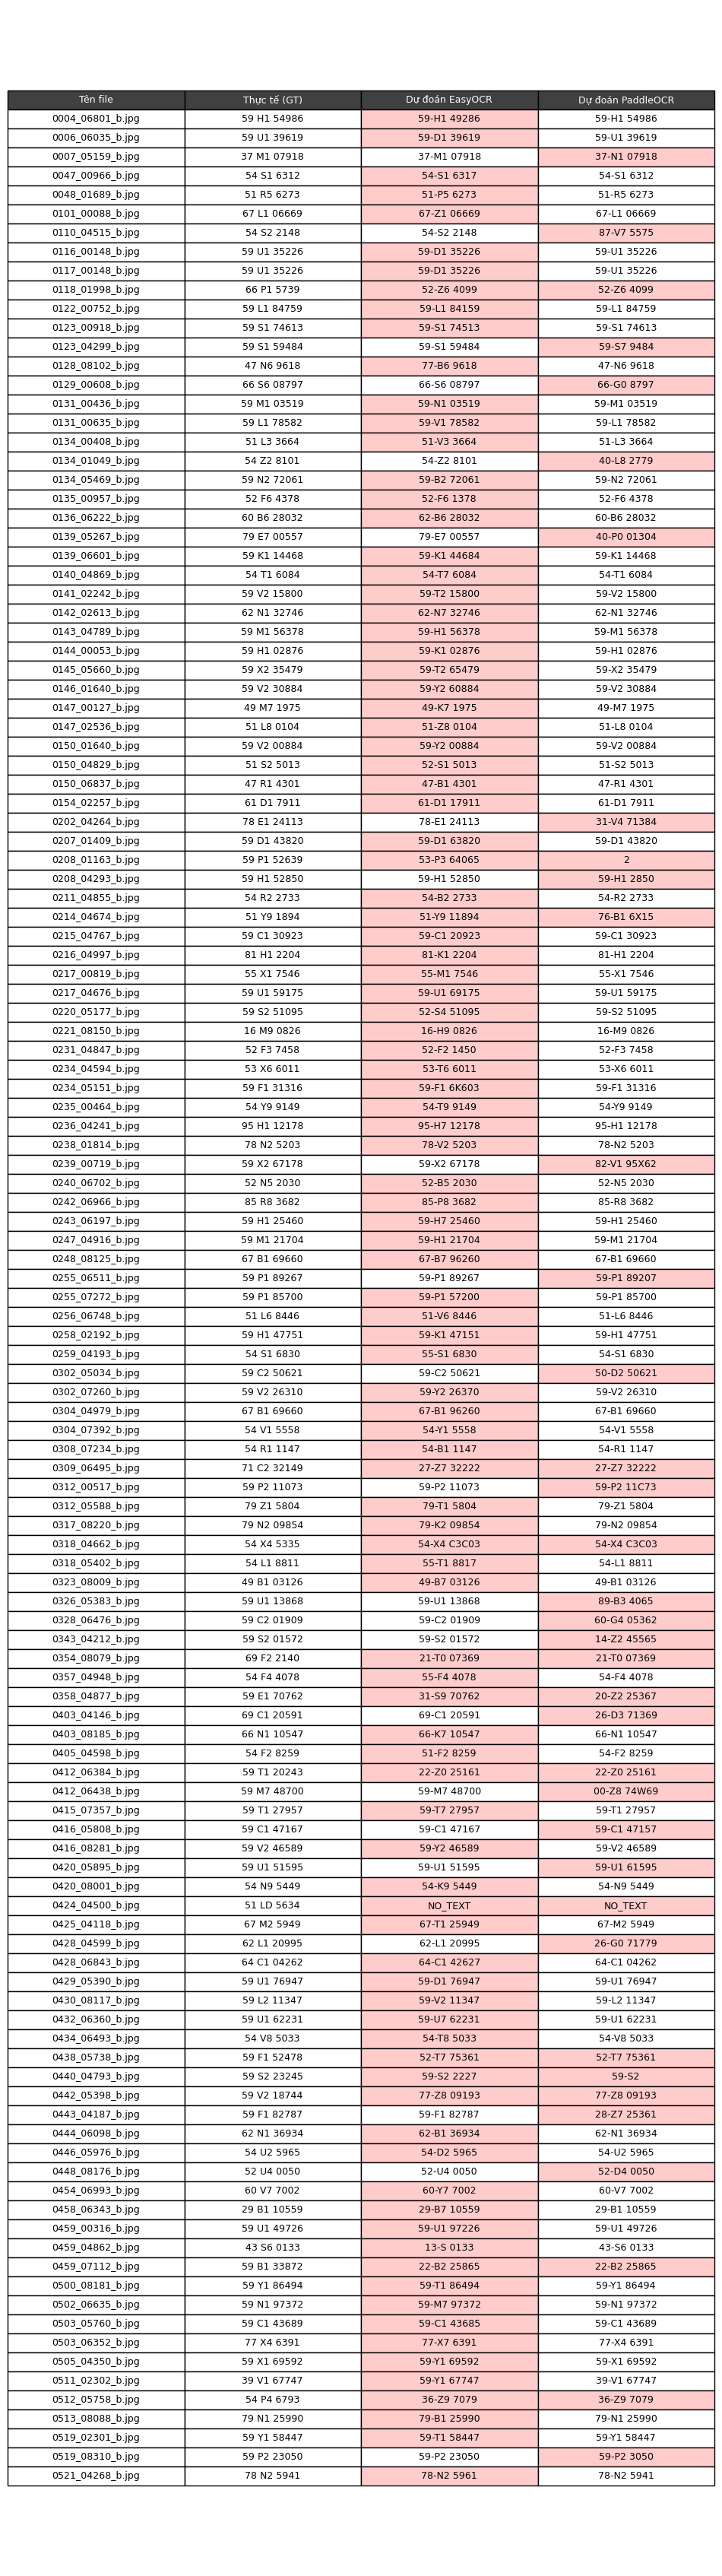

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def create_full_error_image():
    easy_df = pd.read_csv('/Users/binhminh/Project-II/models/ocr/output/results_easy_ocr.csv')
    paddle_df = pd.read_csv('/Users/binhminh/Project-II/models/ocr/output/results_paddle_ocr.csv')
    loc_df = pd.read_csv('/Users/binhminh/Project-II/data/vietnam-car-license-plate/Bike/GreenParking/location.csv')
    
    merged = loc_df[['filename', 'full_plate']].merge(
        easy_df[['filename', 'predicted_plate', 'ca_full']].rename(columns={'predicted_plate': 'EasyOCR', 'ca_full': 'Easy_OK'}),
        on='filename'
    ).merge(
        paddle_df[['filename', 'predicted_plate', 'ca_full']].rename(columns={'predicted_plate': 'PaddleOCR', 'ca_full': 'Paddle_OK'}),
        on='filename'
    )
    
    errors = merged[(merged['Easy_OK'] == False) | (merged['Paddle_OK'] == False)]
    
    num_rows = len(errors)
    fig_height = num_rows * 0.35 
    fig, ax = plt.subplots(figsize=(12, fig_height))
    ax.axis('off')

    table_data = errors[['filename', 'full_plate', 'EasyOCR', 'PaddleOCR']].values
    columns = ['Tên file', 'Thực tế (GT)', 'Dự đoán EasyOCR', 'Dự đoán PaddleOCR']
    
    table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)

    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor('#404040')
            cell.get_text().set_color('white')
            continue
        
        row_idx = i - 1
        if j == 2 and not errors.iloc[row_idx]['Easy_OK']:
            cell.set_facecolor('#ffcccc')
        if j == 3 and not errors.iloc[row_idx]['Paddle_OK']:
            cell.set_facecolor('#ffcccc')

    plt.savefig('full_ocr_error_report.png', bbox_inches='tight', dpi=150)
    print(f"Đã vẽ xong bảng với {num_rows} dòng. Check file 'full_ocr_error_report.png' nhé!")

create_full_error_image()